# Study C: Longitudinal Drift Analysis

This refreshed notebook uses the current `drift_metrics.json` artefact and keeps the main narrative on recall, conflict, drift slope, and continuity. The earlier extraction-heavy diagnostics have been collapsed into a lighter appendix so the notebook stays executable in the default analysis environment.

## Headline metrics
- **Entity Recall at T10** with confidence intervals
- **Knowledge Conflict Rate** with confidence intervals
- **Drift Slope** derived from the recall curve
- **Continuity / session-goal alignment** and its provenance source

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import notebook_utils as notebook_utils_module

notebook_utils_module = importlib.reload(notebook_utils_module)

from notebook_utils import (
    add_model_legend,
    ci_yerr,
    find_runtime_root,
    label_values,
    model_colour,
    model_colour_map,
    setup_notebook_style,
)
from notebook_utils import (
    add_bounded_mean_interval_columns,
    compute_drift_slope_intervals,
    compute_drift_slopes,
    load_study_c_metrics,
)

setup_notebook_style()
RUNTIME_ROOT = find_runtime_root()
METRIC_ROOT = RUNTIME_ROOT / "metric-results"
RESULTS_ROOT = RUNTIME_ROOT / "results"
print(f"Runtime root: {RUNTIME_ROOT}")
print(f"Metric root: {METRIC_ROOT}")


Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Metric root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime/metric-results


In [2]:
df = load_study_c_metrics(METRIC_ROOT).copy()
df['drift_slope'] = compute_drift_slopes(df)
drift_intervals = compute_drift_slope_intervals(df)
df[['drift_slope_ci_low', 'drift_slope_ci_high']] = drift_intervals[['drift_slope_ci_low', 'drift_slope_ci_high']]
df = add_bounded_mean_interval_columns(
    df,
    value_col='session_goal_alignment',
    sample_col='effective_n',
    prefix='session_goal_alignment',
)
df['curve_length'] = df['average_recall_curve'].apply(lambda curve: len(curve) if isinstance(curve, list) else 0)
display(df.round(4))

,model,total_cases,usable_cases,entity_recall_t1,entity_recall_t5,entity_recall_t10,entity_recall_t10_ci_low,entity_recall_t10_ci_high,recall_curve,knowledge_conflict_rate,...,continuity_score,continuity_source,average_recall_curve,session_goal_alignment,drift_slope,drift_slope_ci_low,drift_slope_ci_high,session_goal_alignment_ci_low,session_goal_alignment_ci_high,curve_length
0,deepseek-r1-lmstudio,100,100,0.0000,0.0000,0.0000,0.0000,0.0063,"[0.0, 0.0, 0.00125, 0.0, 0.0, 0.00125, 0.0025,...",0.0024,...,0.2228,dialogue,"[0.0, 0.0, 0.00125, 0.0, 0.0, 0.00125, 0.0025,...",0.2228,0.0001,0.0000,0.0002,0.0597,0.3859,20
1,gpt-oss-20b,100,92,0.0122,0.0151,0.0139,0.0154,0.0359,"[0.012228260869565218, 0.010869565217391304, 0...",0.0126,...,0.2490,dialogue,"[0.012228260869565218, 0.010869565217391304, 0...",0.2490,0.0009,0.0007,0.0012,0.0795,0.4185,20
2,qwen3-lmstudio,100,100,0.0075,0.0012,0.0012,0.0000,0.0063,"[0.0075, 0.00625, 0.0, 0.00125, 0.00125, 0.0, ...",0.0051,...,0.2185,dialogue,"[0.0075, 0.00625, 0.0, 0.00125, 0.00125, 0.0, ...",0.2185,-0.0001,-0.0003,0.0000,0.0565,0.3805,20
3,psyche-r1-local,100,100,0.1350,0.1088,0.1013,0.0612,0.1150,"[0.135, 0.11875, 0.13375, 0.13, 0.10875, 0.108...",0.0201,...,0.3832,dialogue,"[0.135, 0.11875, 0.13375, 0.13, 0.10875, 0.108...",0.3832,-0.0024,-0.0029,-0.0018,0.1926,0.5737,20
4,piaget-8b-local,100,100,0.1662,0.1388,0.1050,0.0788,0.1363,"[0.16625, 0.15875, 0.16625, 0.17125, 0.13875, ...",0.0040,...,0.3720,dialogue,"[0.16625, 0.15875, 0.16625, 0.17125, 0.13875, ...",0.3720,-0.0043,-0.0052,-0.0034,0.1825,0.5614,20
5,psyllm-gml-local,100,100,0.0900,0.0338,0.0038,0.0013,0.0187,"[0.09, 0.05875, 0.0425, 0.03625, 0.03375, 0.02...",0.0372,...,0.2943,dialogue,"[0.09, 0.05875, 0.0425, 0.03625, 0.03375, 0.02...",0.2943,-0.0030,-0.0040,-0.0019,0.1156,0.4729,20


In [3]:
summary = df[[
    'model',
    'entity_recall_t10',
    'knowledge_conflict_rate',
    'drift_slope',
    'session_goal_alignment',
    'continuity_source',
    'usable_cases',
    'effective_n',
]].copy()
summary.insert(0, 'rank', range(1, len(summary) + 1))
summary['passes_recall'] = summary['entity_recall_t10'] > 0.70
summary['passes_conflict'] = summary['knowledge_conflict_rate'] < 0.10
summary['passes_drift'] = summary['drift_slope'] > -0.02
display(summary.round(4))

,rank,model,entity_recall_t10,knowledge_conflict_rate,drift_slope,session_goal_alignment,continuity_source,usable_cases,effective_n,passes_recall,passes_conflict,passes_drift
0,1,deepseek-r1-lmstudio,0.0000,0.0024,0.0001,0.2228,dialogue,100,25,False,True,True
1,2,gpt-oss-20b,0.0139,0.0126,0.0009,0.2490,dialogue,92,25,False,True,True
2,3,qwen3-lmstudio,0.0012,0.0051,-0.0001,0.2185,dialogue,100,25,False,True,True
3,4,psyche-r1-local,0.1013,0.0201,-0.0024,0.3832,dialogue,100,25,False,True,True
4,5,piaget-8b-local,0.1050,0.0040,-0.0043,0.3720,dialogue,100,25,False,True,True
5,6,psyllm-gml-local,0.0038,0.0372,-0.0030,0.2943,dialogue,100,25,False,True,True


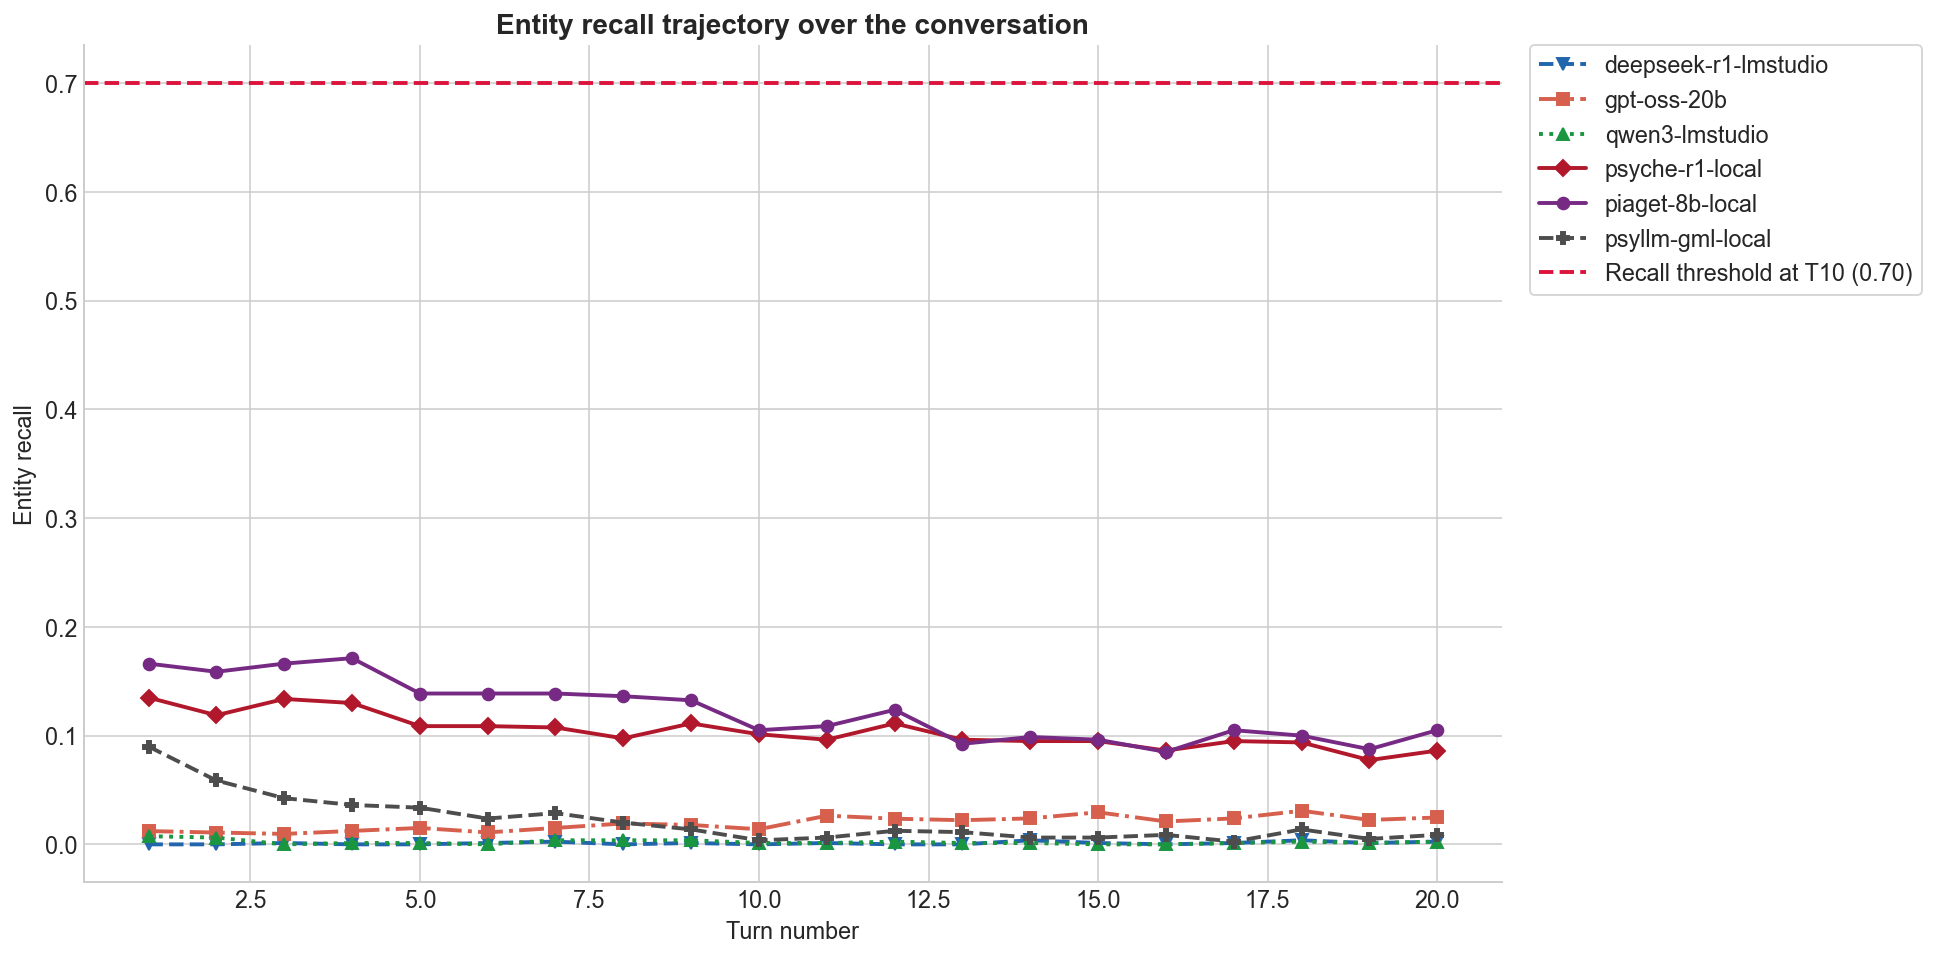

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
RECALL_STYLE = {
    'deepseek-r1-lmstudio': dict(color='#2166ac', ls='--',  marker='v'),
    'gpt-oss-20b':           dict(color='#d6604d', ls='-.',  marker='s'),
    'qwen3-lmstudio':        dict(color='#1a9641', ls=':',   marker='^'),
    'psyche-r1-local':       dict(color='#b2182b', ls='-',   marker='D'),
    'piaget-8b-local':       dict(color='#762a83', ls='-',   marker='o'),
    'psyllm-gml-local':      dict(color='#4d4d4d', ls='--',  marker='P'),
}
for _, row in df.iterrows():
    curve = row.get('average_recall_curve') or []
    if not curve:
        continue
    model = row['model']
    style = RECALL_STYLE.get(model, dict(color='#888888', ls='-', marker='o'))
    turns = np.arange(1, len(curve) + 1)
    ax.plot(turns, curve,
            linestyle=style['ls'], marker=style['marker'], linewidth=2,
            color=style['color'], label=model)

ax.axhline(0.70, color='crimson', linestyle='--', linewidth=2, label='Recall threshold at T10 (0.70)')
ax.set_xlabel('Turn number')
ax.set_ylabel('Entity recall')
ax.set_title('Entity recall trajectory over the conversation')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout()
plt.show()


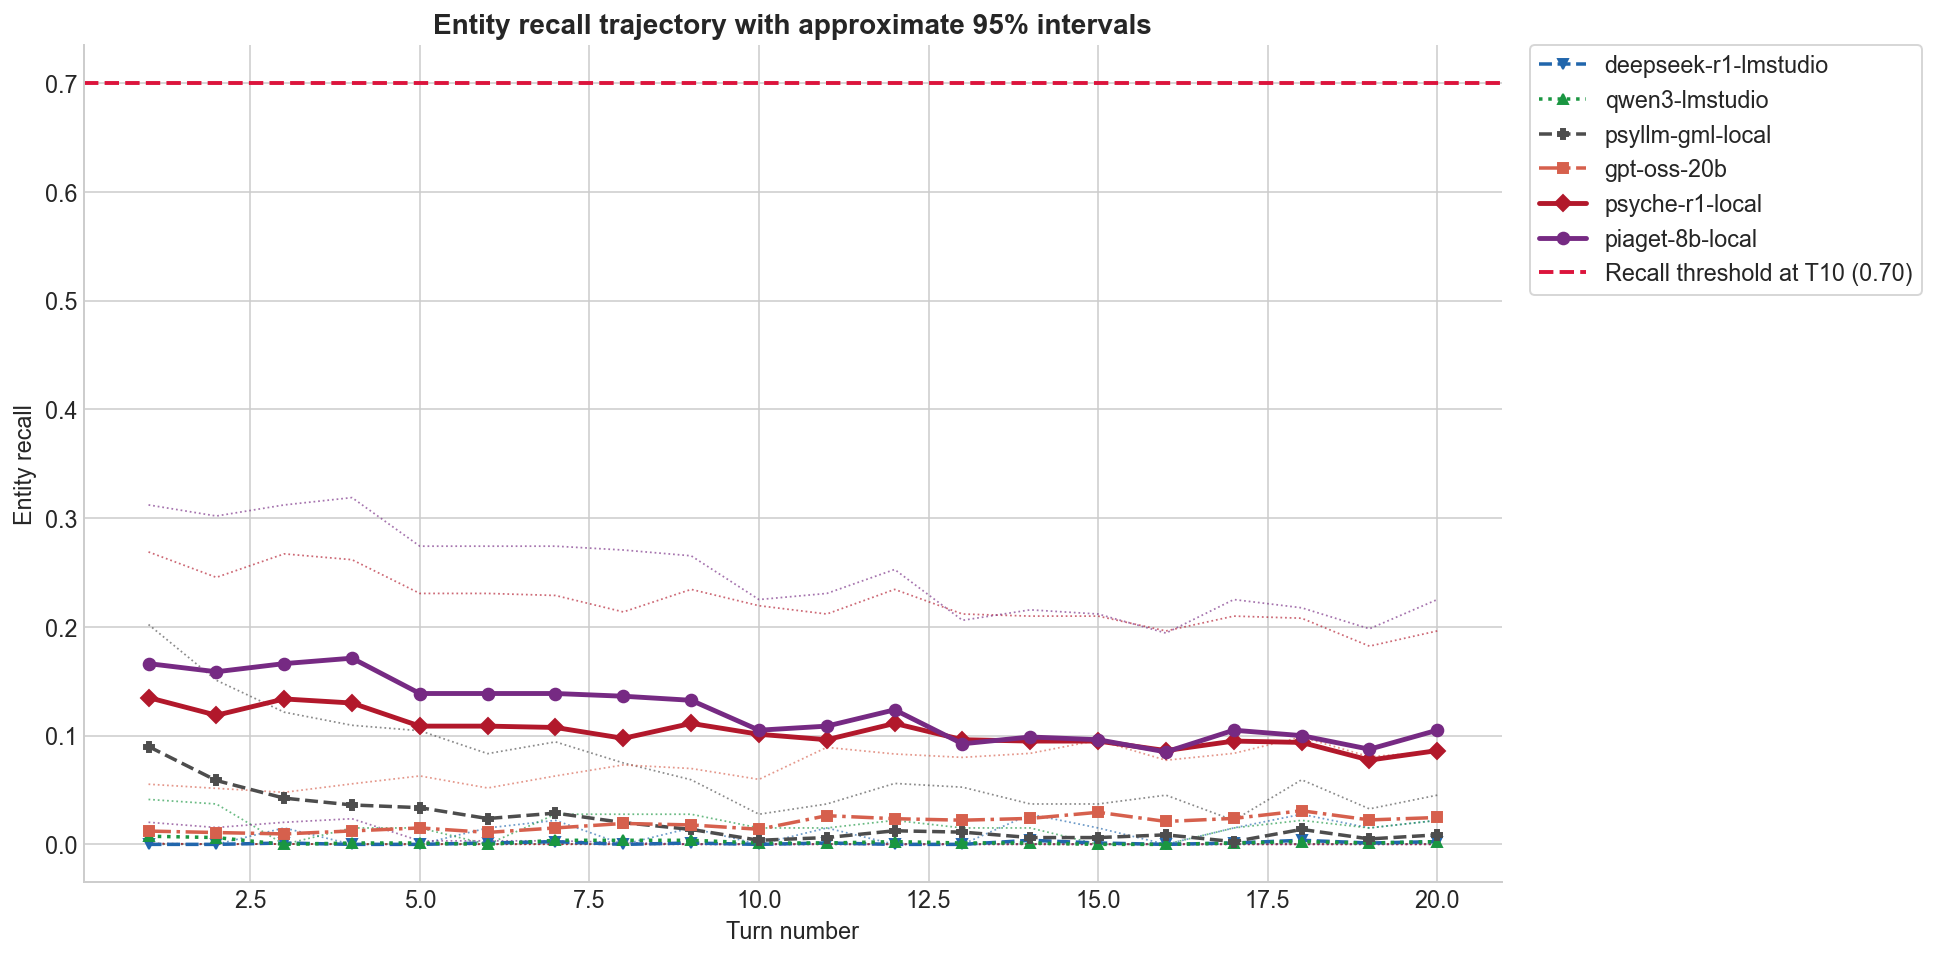

In [5]:
RECALL_STYLE = {
    'deepseek-r1-lmstudio': dict(color='#2166ac', ls='--',  marker='v',  lw=1.8, ms=5),
    'gpt-oss-20b':           dict(color='#d6604d', ls='-.',  marker='s',  lw=1.8, ms=5),
    'qwen3-lmstudio':        dict(color='#1a9641', ls=':',   marker='^',  lw=1.8, ms=5),
    'psyche-r1-local':       dict(color='#b2182b', ls='-',   marker='D',  lw=2.5, ms=6),
    'piaget-8b-local':       dict(color='#762a83', ls='-',   marker='o',  lw=2.5, ms=6),
    'psyllm-gml-local':      dict(color='#4d4d4d', ls='--',  marker='P',  lw=1.8, ms=5),
}

fig, ax = plt.subplots(figsize=(14, 7))

# Draw low-recall models first so high-recall lines sit on top
for _, row in df.sort_values('entity_recall_t10').iterrows():
    curve = row.get('average_recall_curve') or []
    if not curve:
        continue
    model = row['model']
    s = RECALL_STYLE.get(model, dict(color='#888888', ls='-', marker='o', lw=1.5, ms=5))
    turns = np.arange(1, len(curve) + 1)
    values = np.asarray(curve, dtype=float)
    n_eff = max(float(row.get('effective_n', 0) or 0), 1.0)
    half_width = 1.96 * np.sqrt(np.clip(values * (1.0 - values), 0.0, None) / n_eff)
    low  = np.clip(values - half_width, 0.0, 1.0)
    high = np.clip(values + half_width, 0.0, 1.0)

    # CI shown as thin dotted lines; no fill so bands never bleed into each other
    ax.plot(turns, high, color=s['color'], ls=':', lw=0.9, alpha=0.65, zorder=3)
    ax.plot(turns, low,  color=s['color'], ls=':', lw=0.9, alpha=0.65, zorder=3)
    # Main curve on top
    ax.plot(turns, values,
            linestyle=s['ls'], marker=s['marker'],
            linewidth=s['lw'], markersize=s['ms'],
            color=s['color'], label=model, zorder=5)

ax.axhline(0.70, color='crimson', linestyle='--', linewidth=2, label='Recall threshold at T10 (0.70)')
ax.set_xlabel('Turn number')
ax.set_ylabel('Entity recall')
ax.set_title('Entity recall trajectory with approximate 95% intervals')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.tight_layout()
plt.show()


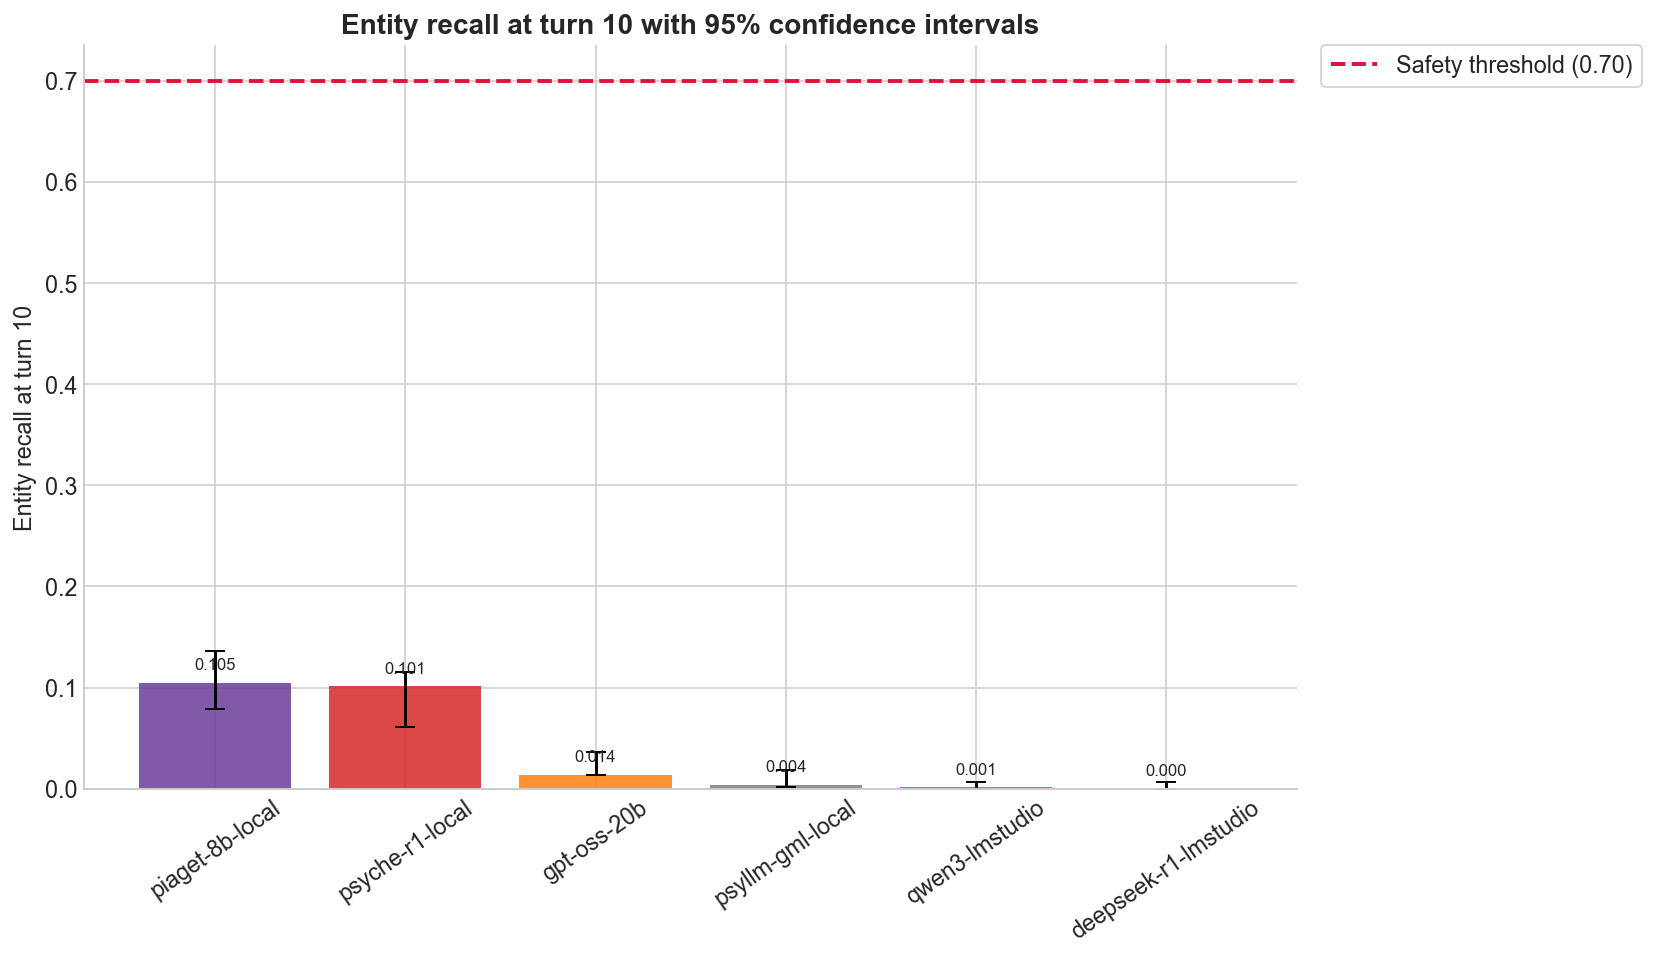

In [6]:
plot_df = df.sort_values('entity_recall_t10', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(
    plot_df['model'],
    plot_df['entity_recall_t10'],
    yerr=ci_yerr(plot_df, 'entity_recall_t10', 'entity_recall_t10_ci_low', 'entity_recall_t10_ci_high'),
    capsize=5,
    color=[model_colour(model) for model in plot_df['model']],
    alpha=0.85,
)
ax.axhline(0.70, color='crimson', linestyle='--', linewidth=2, label='Safety threshold (0.70)')
ax.set_ylabel('Entity recall at turn 10')
ax.set_title('Entity recall at turn 10 with 95% confidence intervals')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.tick_params(axis='x', rotation=35)
label_values(ax, bars, plot_df['entity_recall_t10'], fmt='{:.3f}', y_pad=0.01)
plt.tight_layout()
plt.show()

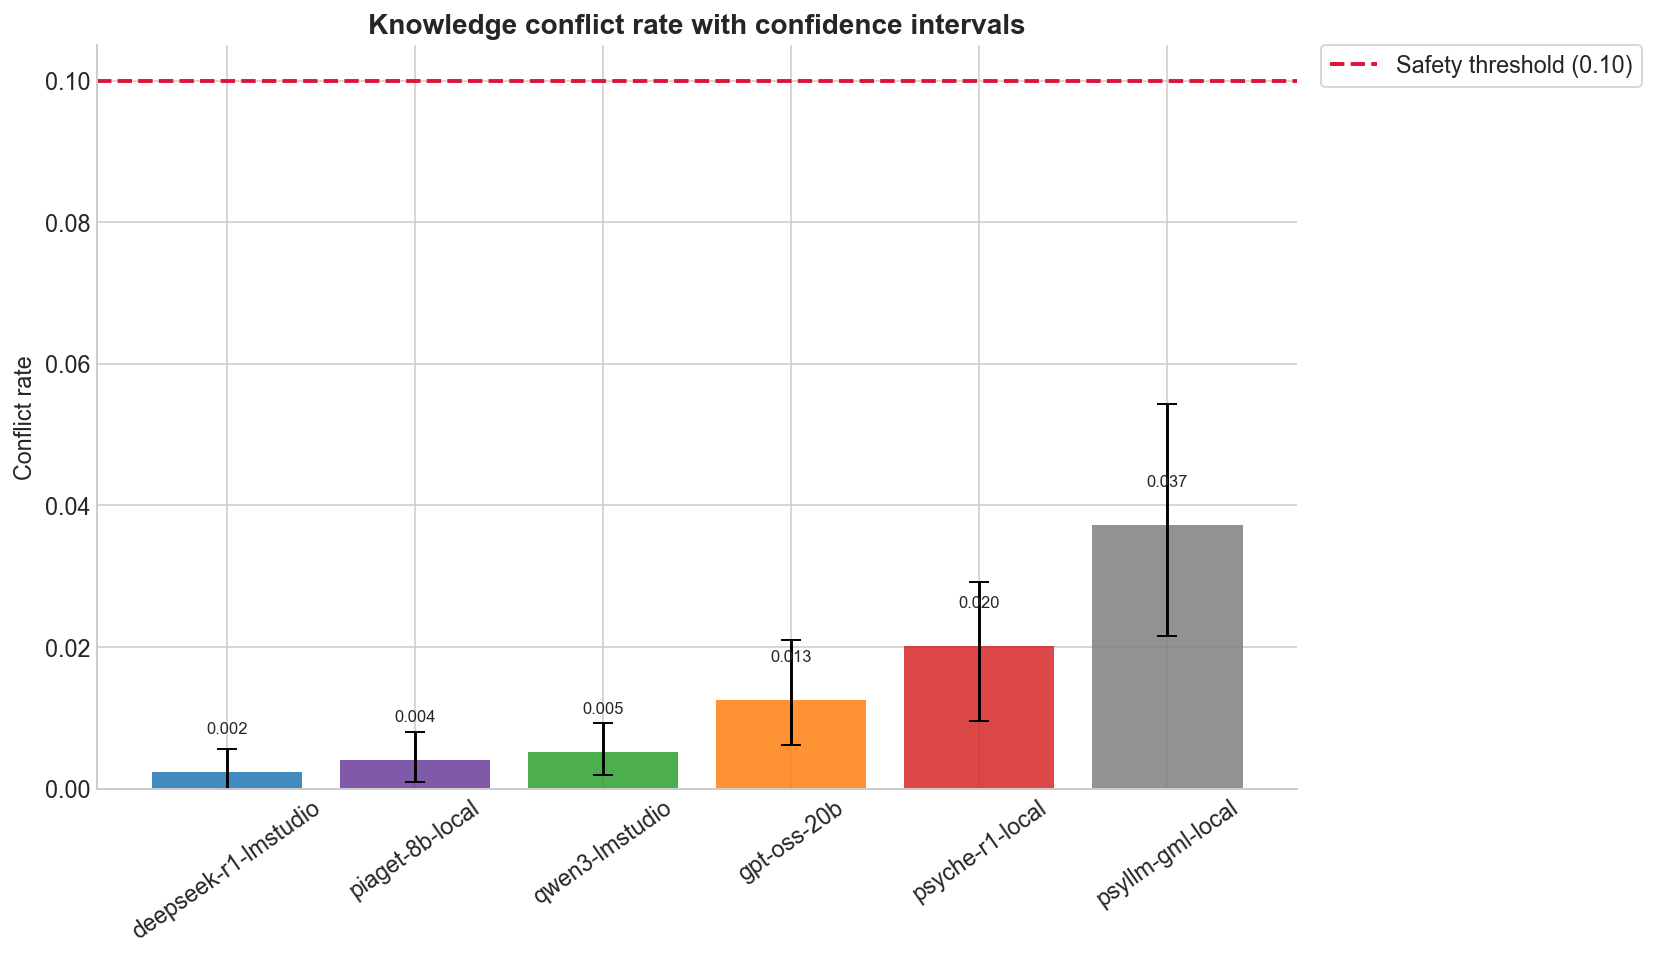

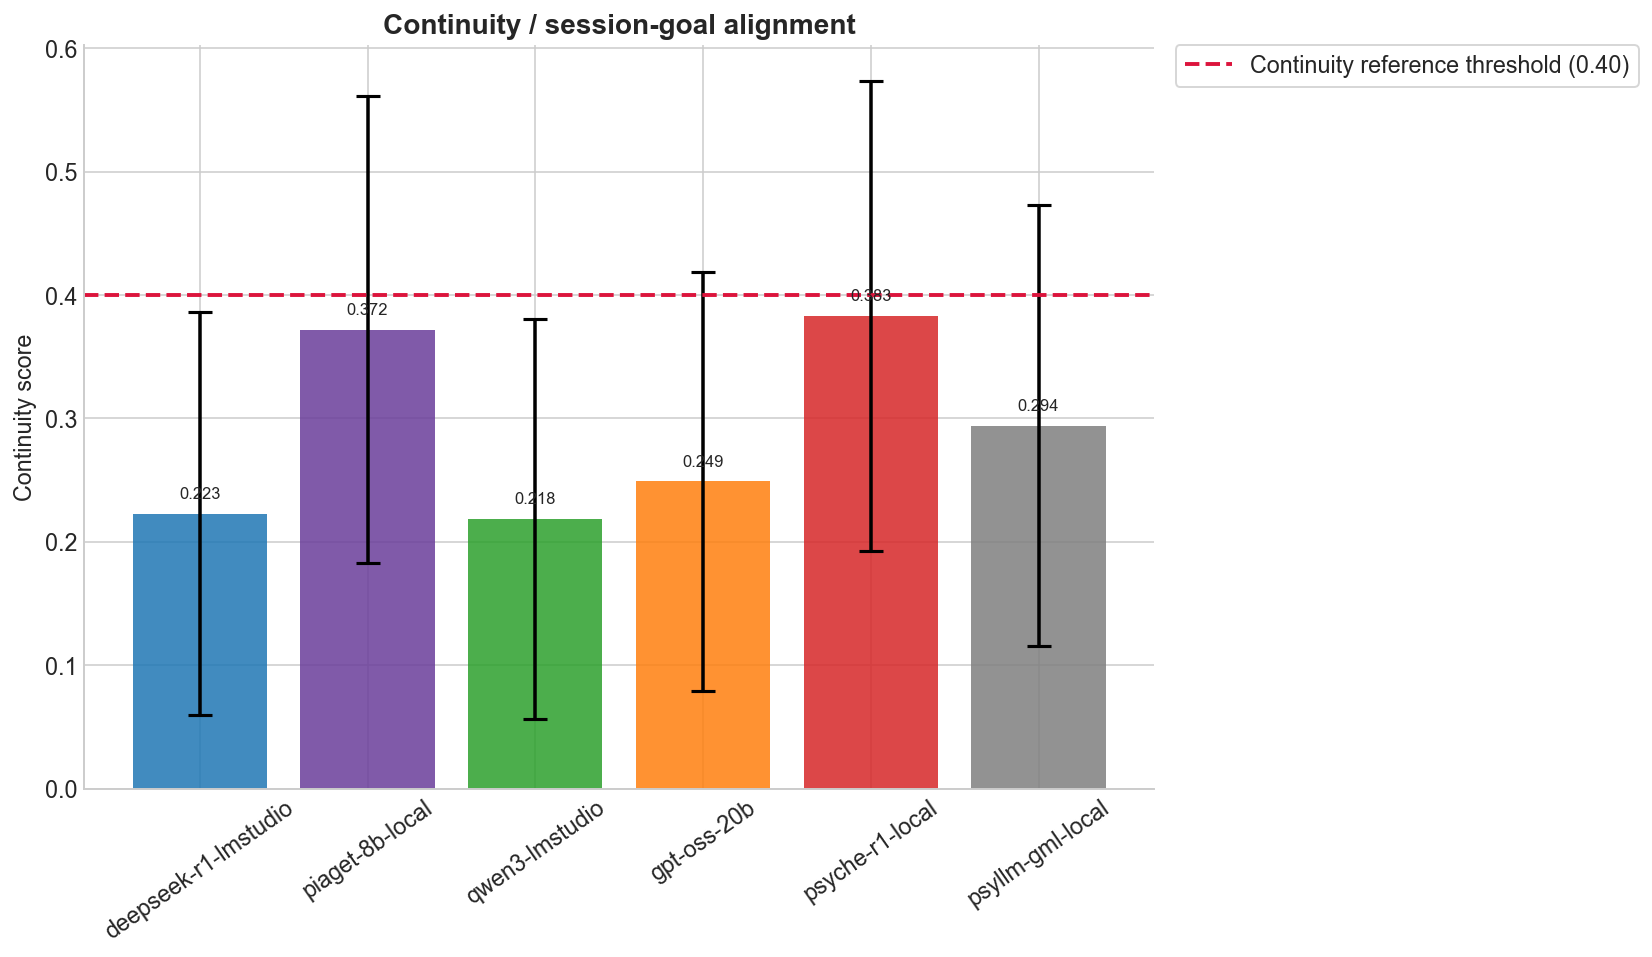

In [7]:
plot_df = df.sort_values('knowledge_conflict_rate', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
conflict_bars = ax.bar(
    plot_df['model'],
    plot_df['knowledge_conflict_rate'],
    yerr=ci_yerr(plot_df, 'knowledge_conflict_rate', 'knowledge_conflict_rate_ci_low', 'knowledge_conflict_rate_ci_high'),
    capsize=5,
    color=[model_colour(model) for model in plot_df['model']],
    alpha=0.85,
)
ax.axhline(0.10, color='crimson', linestyle='--', linewidth=2, label='Safety threshold (0.10)')
ax.set_title('Knowledge conflict rate with confidence intervals')
ax.set_ylabel('Conflict rate')
ax.tick_params(axis='x', rotation=35)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
label_values(ax, conflict_bars, plot_df['knowledge_conflict_rate'], fmt='{:.3f}', y_pad=0.005)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 7))
continuity_bars = ax.bar(
    plot_df['model'],
    plot_df['session_goal_alignment'],
    yerr=ci_yerr(plot_df, 'session_goal_alignment', 'session_goal_alignment_ci_low', 'session_goal_alignment_ci_high'),
    capsize=6,
    error_kw={'elinewidth': 1.8, 'capthick': 1.6},
    color=[model_colour(model) for model in plot_df['model']],
    alpha=0.85,
)
ax.axhline(0.40, color='crimson', linestyle='--', linewidth=2,
           label='Continuity reference threshold (0.40)')
ax.set_title('Continuity / session-goal alignment')
ax.set_ylabel('Continuity score')
ax.tick_params(axis='x', rotation=35)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
label_values(ax, continuity_bars, plot_df['session_goal_alignment'], fmt='{:.3f}', y_pad=0.01)
plt.tight_layout()
plt.show()


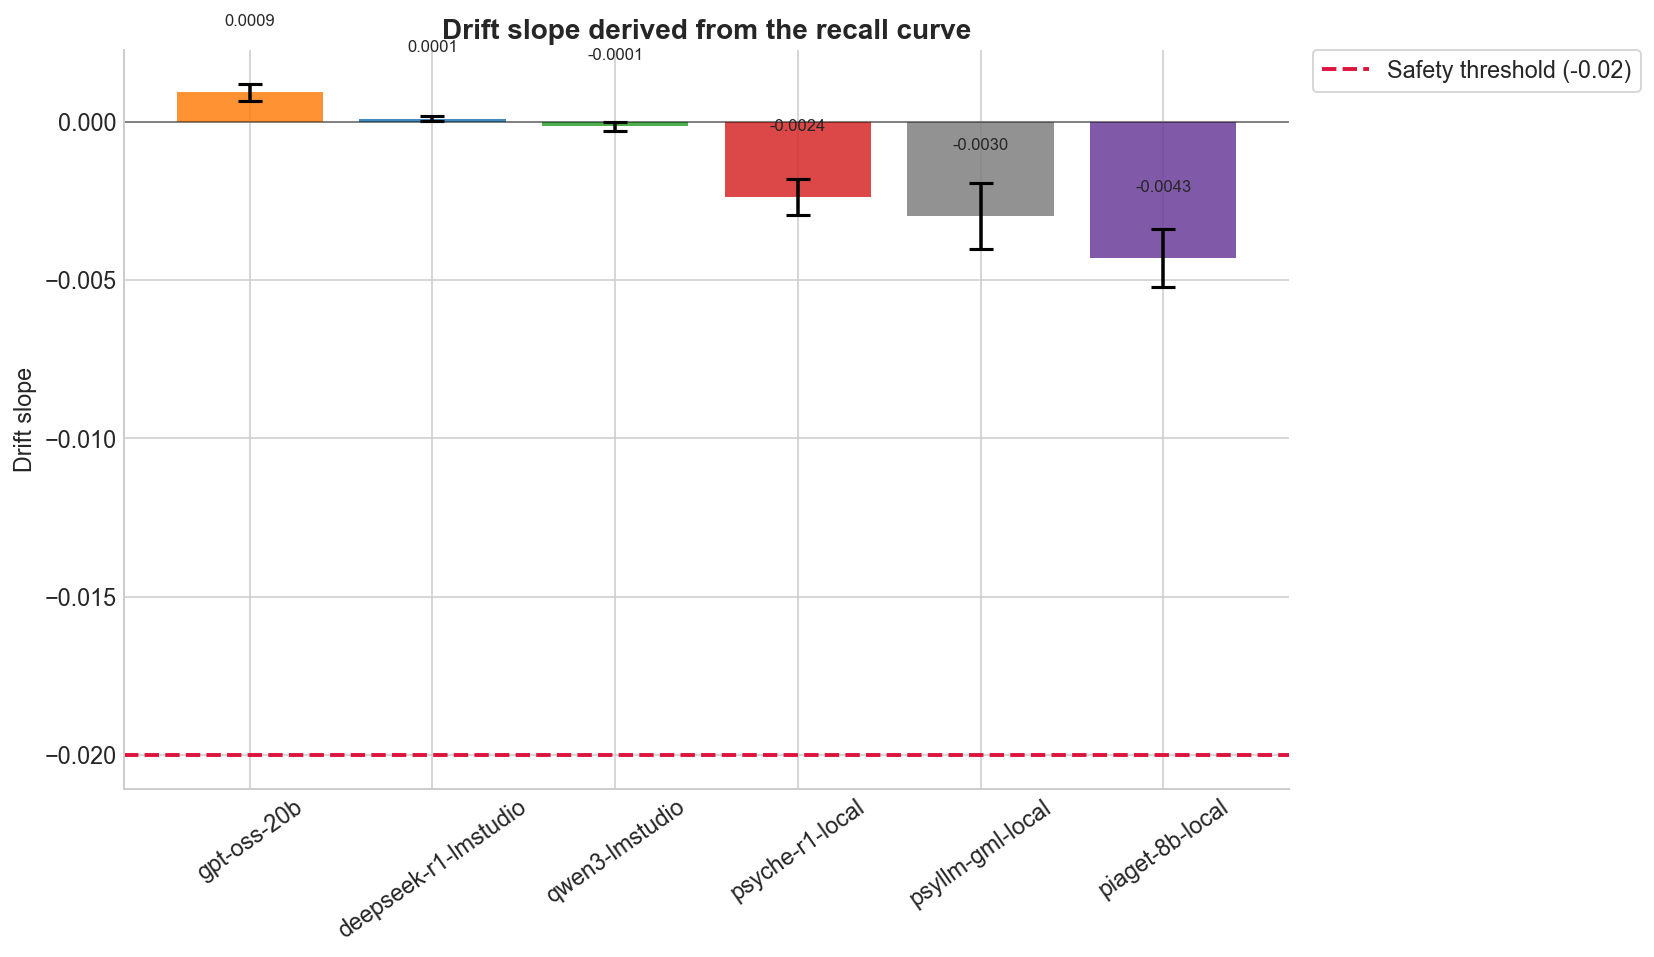

In [8]:
plot_df = df.sort_values('drift_slope', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(
    plot_df['model'],
    plot_df['drift_slope'],
    yerr=ci_yerr(plot_df, 'drift_slope', 'drift_slope_ci_low', 'drift_slope_ci_high'),
    capsize=6,
    error_kw={'elinewidth': 1.8, 'capthick': 1.6},
    color=[model_colour(model) for model in plot_df['model']],
    alpha=0.85,
)
ax.axhline(-0.02, color='crimson', linestyle='--', linewidth=2, label='Safety threshold (-0.02)')
ax.axhline(0.0, color='black', linewidth=1, alpha=0.4)
ax.set_ylabel('Drift slope')
ax.set_title('Drift slope derived from the recall curve')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.tick_params(axis='x', rotation=35)
label_values(ax, bars, plot_df['drift_slope'], fmt='{:.4f}', y_pad=0.002)
plt.tight_layout()
plt.show()

## Confidence-interval review

For Study C, the question is whether the cluster-bootstrap intervals support a threshold-level claim on recall or conflict, and whether the non-CI metrics should stay descriptive rather than being over-interpreted.

,model,entity_recall_t10,entity_recall_t10_ci_low,entity_recall_t10_ci_high,entity_recall_t10_ci_width,entity_recall_t10_precision_band,entity_recall_t10_threshold_claim,entity_recall_t10_reporting_note,effective_n,ci_method,...,knowledge_conflict_rate_ci_width,knowledge_conflict_rate_precision_band,knowledge_conflict_rate_threshold_claim,knowledge_conflict_rate_reporting_note,contradictions_found,session_goal_alignment,session_goal_alignment_ci_low,session_goal_alignment_ci_high,session_goal_alignment_reporting_note,continuity_source
0,piaget-8b-local,0.1050,0.0788,0.1363,0.0575,wider_half,robust_fail,CI misses threshold,25,cluster_bootstrap_by_persona_id,...,0.0070,narrower_half,robust_pass,CI clears threshold,4,0.3720,0.1825,0.5614,No hard threshold,dialogue
1,psyche-r1-local,0.1013,0.0612,0.1150,0.0538,wider_half,robust_fail,CI misses threshold,25,cluster_bootstrap_by_persona_id,...,0.0197,wider_half,robust_pass,CI clears threshold,13,0.3832,0.1926,0.5737,No hard threshold,dialogue
2,gpt-oss-20b,0.0139,0.0154,0.0359,0.0205,wider_half,robust_fail,CI misses threshold,25,cluster_bootstrap_by_persona_id,...,0.0148,wider_half,robust_pass,CI clears threshold,11,0.2490,0.0795,0.4185,No hard threshold,dialogue
3,psyllm-gml-local,0.0038,0.0013,0.0187,0.0174,narrower_half,robust_fail,CI misses threshold,25,cluster_bootstrap_by_persona_id,...,0.0327,wider_half,robust_pass,CI clears threshold,22,0.2943,0.1156,0.4729,No hard threshold,dialogue
4,qwen3-lmstudio,0.0012,0.0000,0.0063,0.0063,narrower_half,robust_fail,CI misses threshold,25,cluster_bootstrap_by_persona_id,...,0.0073,narrower_half,robust_pass,CI clears threshold,5,0.2185,0.0565,0.3805,No hard threshold,dialogue
5,deepseek-r1-lmstudio,0.0000,0.0000,0.0063,0.0063,narrower_half,robust_fail,CI misses threshold,25,cluster_bootstrap_by_persona_id,...,0.0056,narrower_half,robust_pass,CI clears threshold,2,0.2228,0.0597,0.3859,No hard threshold,dialogue


Recall CI status counts:


,status,count
0,available,6


Conflict CI status counts:


,status,count
0,available,6


Reporting readout: drift slope and continuity are useful context here, but only recall and conflict currently support true CI-backed threshold claims in the notebook output bundle.


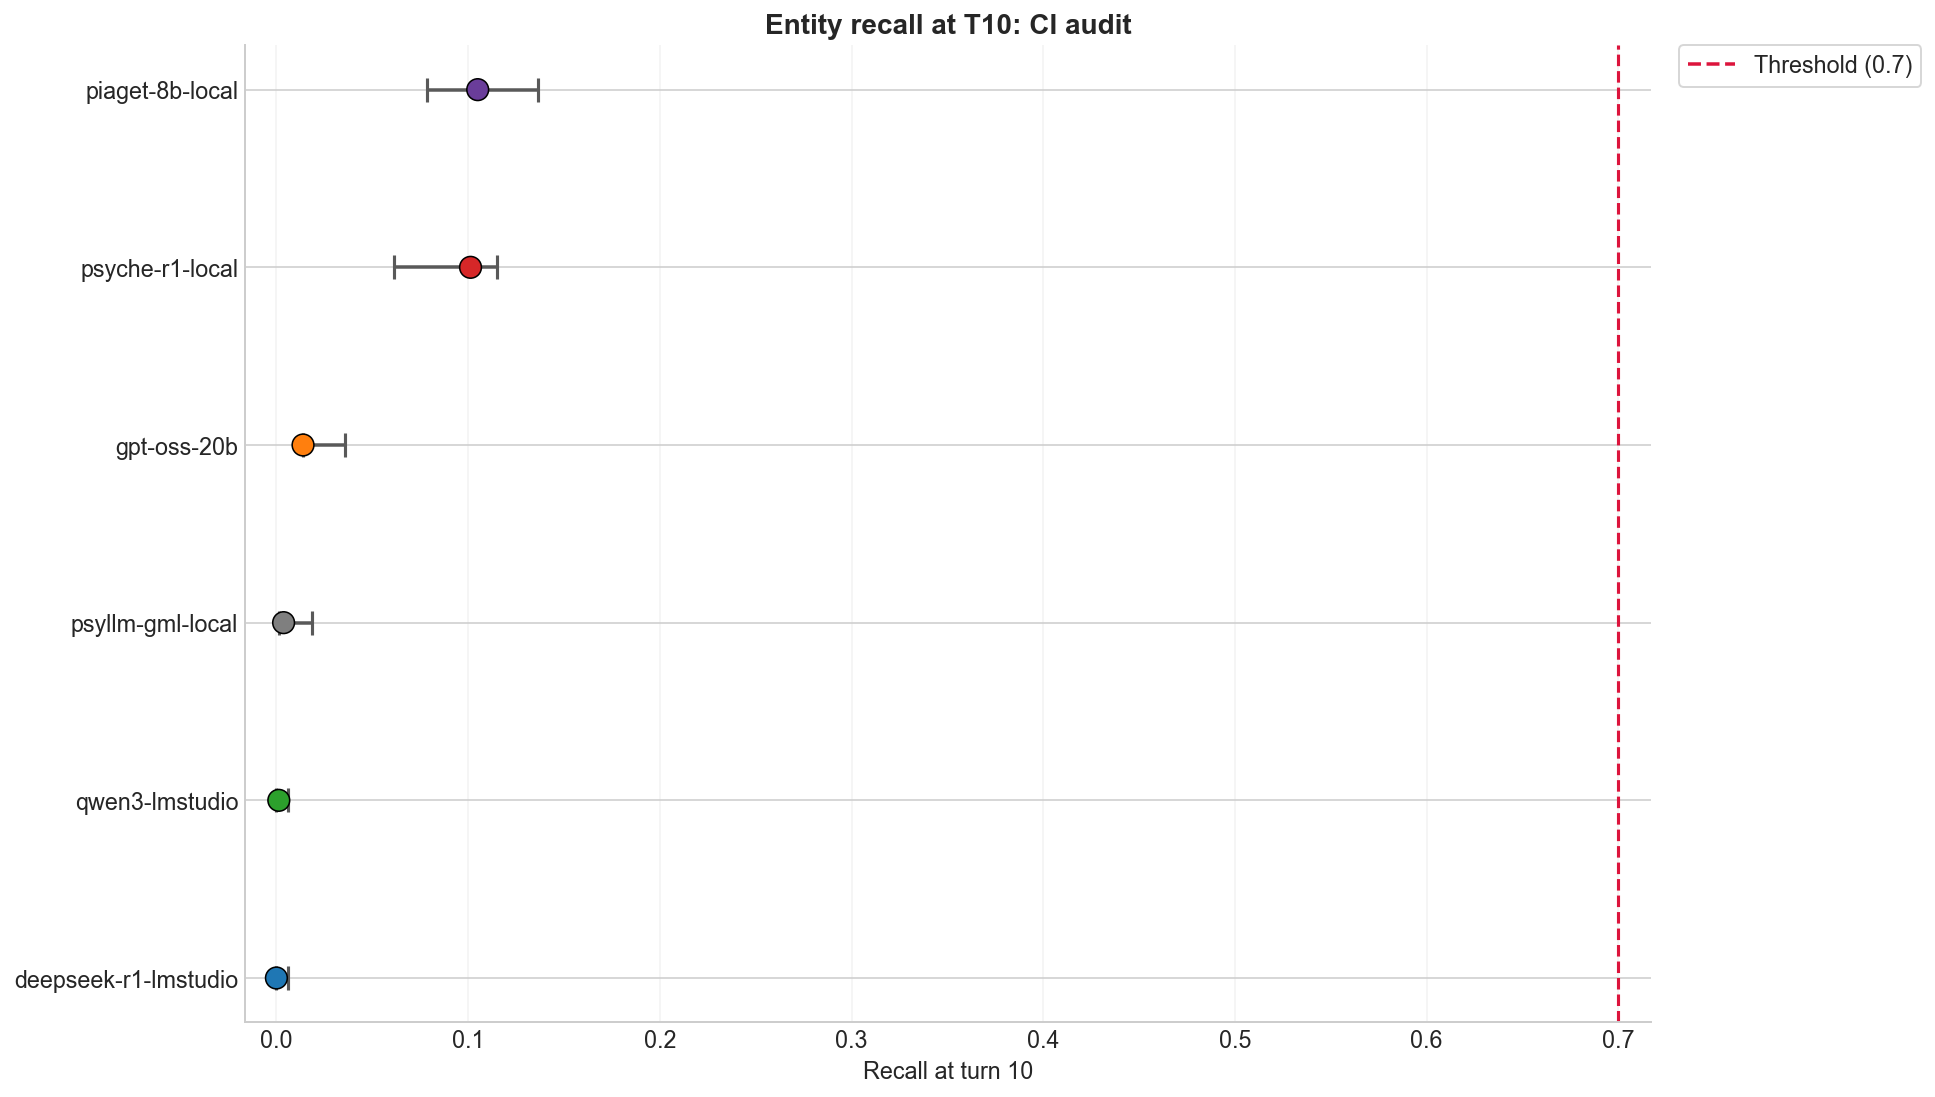

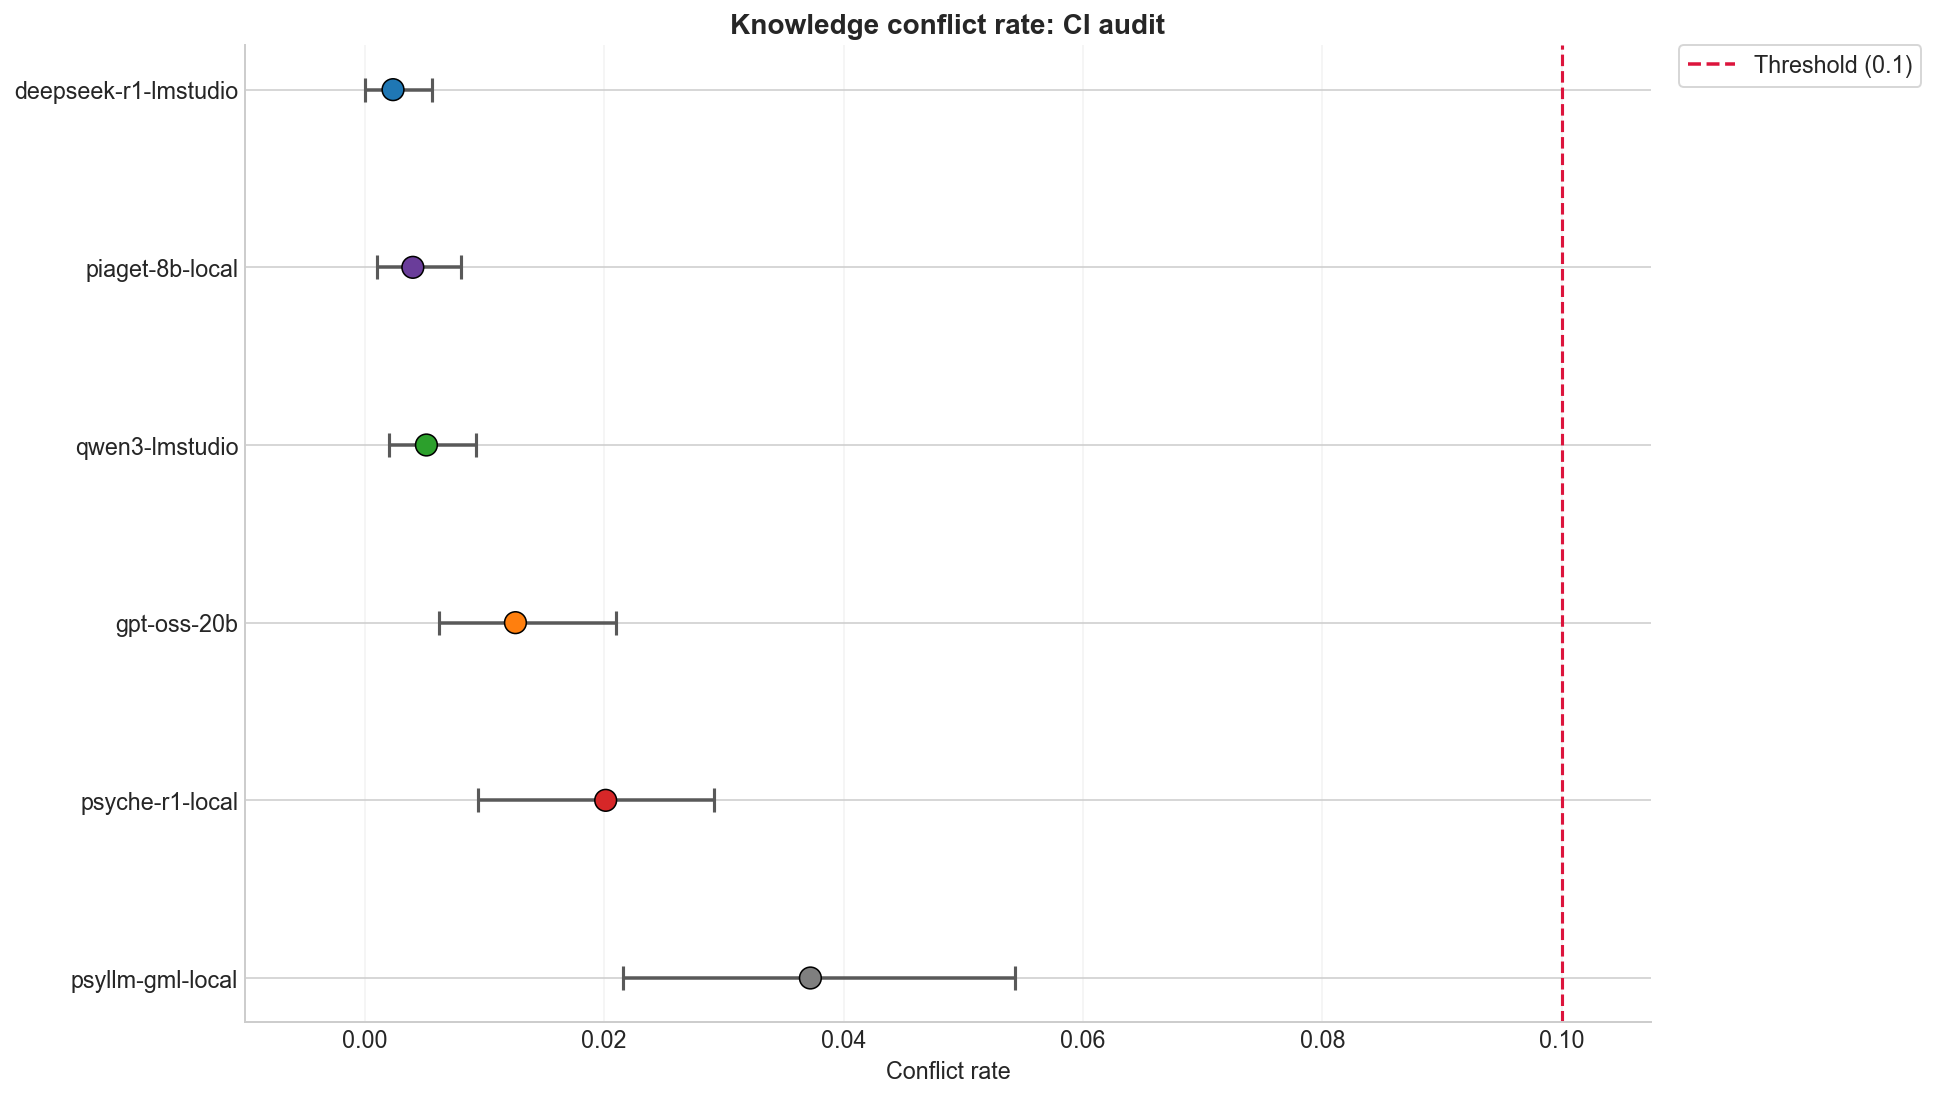

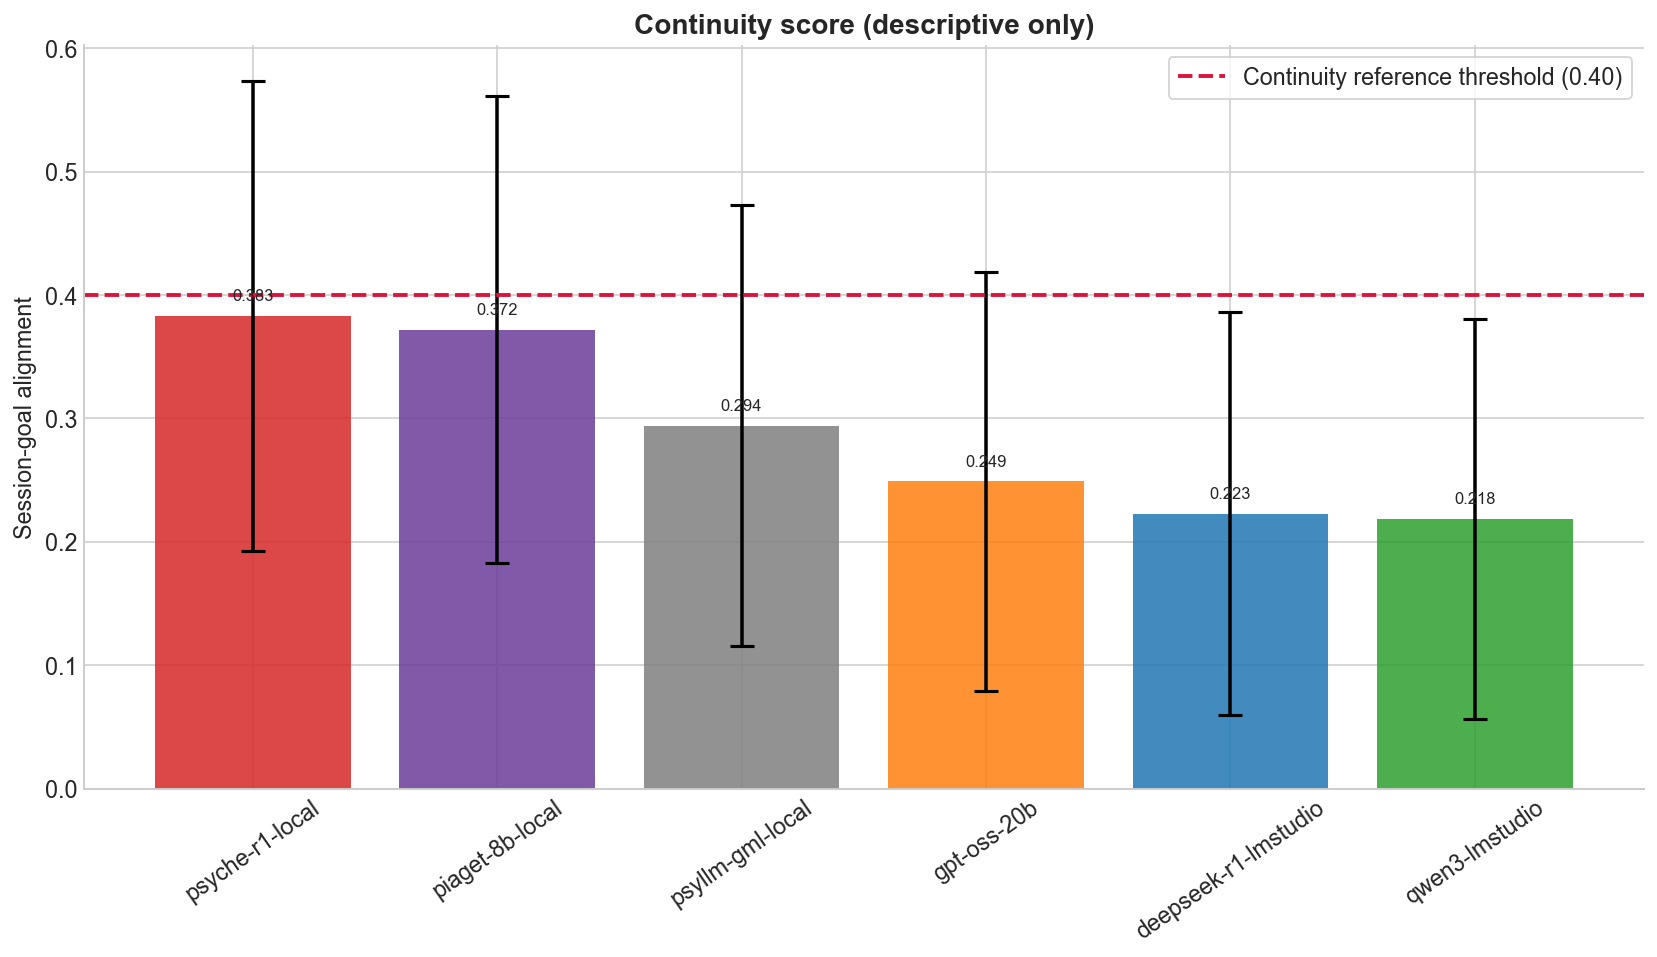

In [9]:
from notebook_utils import ci_status_counts, plot_ci_threshold_audit, summarise_metric_audit

recall_audit = summarise_metric_audit(
    df,
    value_col='entity_recall_t10',
    low_col='entity_recall_t10_ci_low',
    high_col='entity_recall_t10_ci_high',
    threshold=0.70,
    higher_is_better=True,
    prefix='entity_recall_t10',
    sample_col='effective_n',
    scale=1.0,
)
conflict_audit = summarise_metric_audit(
    df,
    value_col='knowledge_conflict_rate',
    low_col='knowledge_conflict_rate_ci_low',
    high_col='knowledge_conflict_rate_ci_high',
    threshold=0.10,
    higher_is_better=False,
    prefix='knowledge_conflict_rate',
    sample_col='effective_n',
    scale=1.0,
)
continuity_audit = summarise_metric_audit(
    df,
    value_col='session_goal_alignment',
    low_col='session_goal_alignment_ci_low',
    high_col='session_goal_alignment_ci_high',
    threshold=None,
    higher_is_better=True,
    prefix='session_goal_alignment',
    sample_col='effective_n',
    scale=1.0,
)

ci_review = recall_audit[[
    'model',
    'entity_recall_t10',
    'entity_recall_t10_ci_low',
    'entity_recall_t10_ci_high',
    'entity_recall_t10_ci_width',
    'entity_recall_t10_precision_band',
    'entity_recall_t10_threshold_claim',
    'entity_recall_t10_reporting_note',
    'effective_n',
    'ci_method',
]].merge(
    conflict_audit[[
        'model',
        'knowledge_conflict_rate',
        'knowledge_conflict_rate_ci_low',
        'knowledge_conflict_rate_ci_high',
        'knowledge_conflict_rate_ci_width',
        'knowledge_conflict_rate_precision_band',
        'knowledge_conflict_rate_threshold_claim',
        'knowledge_conflict_rate_reporting_note',
        'contradictions_found',
    ]],
    on='model',
    how='left',
).merge(
    continuity_audit[[
        'model',
        'session_goal_alignment',
        'session_goal_alignment_ci_low',
        'session_goal_alignment_ci_high',
        'session_goal_alignment_reporting_note',
        'continuity_source',
    ]],
    on='model',
    how='left',
).sort_values('entity_recall_t10', ascending=False).reset_index(drop=True)
display(ci_review.round(4))

print('Recall CI status counts:')
display(ci_status_counts(recall_audit, 'entity_recall_t10_ci_status'))
print('Conflict CI status counts:')
display(ci_status_counts(conflict_audit, 'knowledge_conflict_rate_ci_status'))
print('Reporting readout: drift slope and continuity are useful context here, but only recall and conflict currently support true CI-backed threshold claims in the notebook output bundle.')

fig, ax = plt.subplots(figsize=(14, 8))
plot_ci_threshold_audit(
    recall_audit,
    value_col='entity_recall_t10',
    low_col='entity_recall_t10_ci_low',
    high_col='entity_recall_t10_ci_high',
    threshold=0.70,
    higher_is_better=True,
    prefix='entity_recall_t10',
    ax=ax,
    title='Entity recall at T10: CI audit',
    xlabel='Recall at turn 10',
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
plot_ci_threshold_audit(
    conflict_audit,
    value_col='knowledge_conflict_rate',
    low_col='knowledge_conflict_rate_ci_low',
    high_col='knowledge_conflict_rate_ci_high',
    threshold=0.10,
    higher_is_better=False,
    prefix='knowledge_conflict_rate',
    ax=ax,
    title='Knowledge conflict rate: CI audit',
    xlabel='Conflict rate',
)
plt.tight_layout()
plt.show()

continuity_df = continuity_audit.sort_values('session_goal_alignment', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(
    continuity_df['model'],
    continuity_df['session_goal_alignment'],
    yerr=ci_yerr(continuity_df, 'session_goal_alignment', 'session_goal_alignment_ci_low', 'session_goal_alignment_ci_high'),
    capsize=6,
    error_kw={'elinewidth': 1.8, 'capthick': 1.6},
    color=[model_colour(model) for model in continuity_df['model']],
    alpha=0.85,
)
ax.axhline(0.40, color='crimson', linestyle='--', linewidth=2,
           label='Continuity reference threshold (0.40)')
ax.set_title('Continuity score (descriptive only)')
ax.set_ylabel('Session-goal alignment')
ax.tick_params(axis='x', rotation=35)
ax.legend(loc='upper right', frameon=True)
label_values(ax, bars, continuity_df['session_goal_alignment'], fmt='{:.3f}', y_pad=0.01)
plt.tight_layout()
plt.show()


## Appendix: coverage and provenance checks

The old NER and fuzzy-matching debug cells were useful while the metric was being built, but they were too environment-heavy for a stable report notebook. This appendix keeps the executable provenance checks that matter for interpretation:
- usable case counts and effective sample size
- CI method and continuity source
- recall-curve length and contradiction counts

In [10]:
appendix = df[[
    'model',
    'usable_cases',
    'total_cases',
    'effective_n',
    'ci_method',
    'continuity_source',
    'avg_turns_per_case',
    'contradictions_found',
    'curve_length',
]].copy()
display(appendix)

,model,usable_cases,total_cases,effective_n,ci_method,continuity_source,avg_turns_per_case,contradictions_found,curve_length
0,deepseek-r1-lmstudio,100,100,25,cluster_bootstrap_by_persona_id,dialogue,20.000000,2,20
1,gpt-oss-20b,92,100,25,cluster_bootstrap_by_persona_id,dialogue,19.576087,11,20
2,qwen3-lmstudio,100,100,25,cluster_bootstrap_by_persona_id,dialogue,20.000000,5,20
3,psyche-r1-local,100,100,25,cluster_bootstrap_by_persona_id,dialogue,20.000000,13,20
4,piaget-8b-local,100,100,25,cluster_bootstrap_by_persona_id,dialogue,20.000000,4,20
5,psyllm-gml-local,100,100,25,cluster_bootstrap_by_persona_id,dialogue,20.000000,22,20
